# DCF Valuation Model — Full Build
Five-year unlevered DCF with mid-year discounting, WACC build, sensitivity grids, tornado, scenarios, reverse DCF and Monte Carlo.

**How to use:** Run all cells (Runtime → Run all). Edit only the `BASE` dictionary in section 1; everything else updates.
All figures in **$ millions** unless noted. This is an illustrative model, not investment advice.

## 1. Inputs

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import brentq

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "font.size": 10})
BLUE, GREEN, RED, GREY, ORANGE = "#2563eb", "#16a34a", "#dc2626", "#6b7280", "#f59e0b"

BASE = dict(
    rev0    = 477_070,                                   # FY2026E net sales ($M)
    growth  = [0.07, 0.065, 0.06, 0.055, 0.05],         # FY27E-FY31E
    ebit_m  = [0.323, 0.322, 0.322, 0.323, 0.326],
    tax     = 0.175,
    da_pct  = 0.027,
    capex   = [0.030, 0.032, 0.033, 0.033, 0.033],
    nwc_pct = 0.02,                                      # % of change in revenue
    rf=0.049, erp=0.045, beta=1.05,
    kd=0.048, debt=84_344, price=340.67,
    cash=146_517, shares=14_667.5,                       # swap in diluted shares if you have them
    g=0.03,
    mid_year=True,
    normalize_tv=False,     # True: rebuild terminal-year reinvestment at growth g
    wacc_override=None,     # set e.g. 0.08 to bypass the CAPM build
    growth_shift=0.0,       # additive shift to every year's growth (for scenarios / MC)
    margin_shift=0.0,       # additive shift to every year's EBIT margin
)
years = [f"FY{2027+i}E" for i in range(5)]

## 2. Model engine

In [2]:
def dcf(**over):
    p = {**BASE, **over}
    mcap = p["price"] * p["shares"]
    ke = p["rf"] + p["beta"] * p["erp"]
    wacc = p["wacc_override"] or (mcap*ke + p["debt"]*p["kd"]*(1-p["tax"])) / (mcap + p["debt"])

    rows, rev = [], p["rev0"]
    for i in range(5):
        prev = rev
        rev  = prev * (1 + p["growth"][i] + p["growth_shift"])
        m    = p["ebit_m"][i] + p["margin_shift"]
        ebit = rev * m
        nopat = ebit * (1 - p["tax"])
        da, cx, dnwc = rev*p["da_pct"], rev*p["capex"][i], (rev-prev)*p["nwc_pct"]
        rows.append(dict(Year=years[i], Revenue=rev, Growth=rev/prev-1, EBIT=ebit, Margin=m,
                         NOPAT=nopat, DA=da, Capex=cx, dNWC=dnwc, UFCF=nopat+da-cx-dnwc))
    df = pd.DataFrame(rows)
    t = np.arange(1, 6) - (0.5 if p["mid_year"] else 0)
    df["t"], df["DF"] = t, 1/(1+wacc)**t
    df["PV"] = df["UFCF"] * df["DF"]

    g = p["g"]
    if p["normalize_tv"]:
        r = df.iloc[-1]; rt = r.Revenue*(1+g)
        f_tv = rt*r.Margin*(1-p["tax"]) + rt*(p["da_pct"]-p["capex"][-1]) - (rt-r.Revenue)*p["nwc_pct"]
    else:
        f_tv = df.UFCF.iloc[-1]*(1+g)
    tv    = f_tv/(wacc-g)
    pv_tv = tv/(1+wacc)**t[-1]
    ev    = df.PV.sum() + pv_tv
    eq    = ev + p["cash"] - p["debt"]
    ebitda_T = (df.EBIT + df.DA).iloc[-1]
    return dict(df=df, wacc=wacc, ke=ke, tv=tv, pv_tv=pv_tv, pv_fcf=df.PV.sum(), ev=ev, equity=eq,
                per_share=eq/p["shares"], tv_share=pv_tv/ev, tv_ebitda=tv/ebitda_T,
                tv_fcf_mult=tv/f_tv, p=p)

def vps(**kw): return dcf(**kw)["per_share"]

## 3. Base-case results

In [3]:
R = dcf(); p = R["p"]; df = R["df"]
show = df[["Year","Revenue","Growth","EBIT","Margin","NOPAT","DA","Capex","dNWC","UFCF","DF","PV"]].copy()
fmt = {c:"{:,.0f}" for c in ["Revenue","EBIT","NOPAT","DA","Capex","dNWC","UFCF","PV"]}
fmt.update({"Growth":"{:.1%}","Margin":"{:.1%}","DF":"{:.3f}"})
display(show.style.format(fmt).hide(axis="index"))

summary = pd.Series({
    "Cost of equity": f"{R['ke']:.2%}", "WACC": f"{R['wacc']:.2%}", "Terminal growth": f"{p['g']:.1%}",
    "PV of FCF (5y)": f"${R['pv_fcf']/1e3:,.0f}B", "PV of terminal value": f"${R['pv_tv']/1e3:,.0f}B",
    "Enterprise value": f"${R['ev']/1e3:,.0f}B", "Equity value": f"${R['equity']/1e3:,.0f}B",
    "TV % of EV": f"{R['tv_share']:.0%}", "Implied TV / FY31 EBITDA": f"{R['tv_ebitda']:.1f}x",
    "Implied TV / FCF": f"{R['tv_fcf_mult']:.1f}x",
    "Intrinsic value / share": f"${R['per_share']:,.2f}", "Market price": f"${p['price']:,.2f}",
    "Upside / (downside)": f"{R['per_share']/p['price']-1:+.1%}"}, name="Base case")
display(summary.to_frame())

Year,Revenue,Growth,EBIT,Margin,NOPAT,DA,Capex,dNWC,UFCF,DF,PV
FY2027E,"510,465",7.0%,"164,880",32.3%,"136,026","13,783","15,314",668,"133,827",0.956,"127,872"
FY2028E,"543,645",6.5%,"175,054",32.2%,"144,419","14,678","17,397",664,"141,037",0.872,"123,035"
FY2029E,"576,264",6.0%,"185,557",32.2%,"153,084","15,559","19,017",652,"148,975",0.796,"118,651"
FY2030E,"607,958",5.5%,"196,371",32.3%,"162,006","16,415","20,063",634,"157,724",0.727,"114,688"
FY2031E,"638,356",5.0%,"208,104",32.6%,"171,686","17,236","21,066",608,"167,248",0.664,"111,031"


,Base case
Cost of equity,9.62%
WACC,9.53%
Terminal growth,3.0%
PV of FCF (5y),$595B
PV of terminal value,"$1,751B"
Enterprise value,"$2,346B"
Equity value,"$2,409B"
TV % of EV,75%
Implied TV / FY31 EBITDA,11.7x
Implied TV / FCF,15.3x


## 4. Operating forecast & value composition

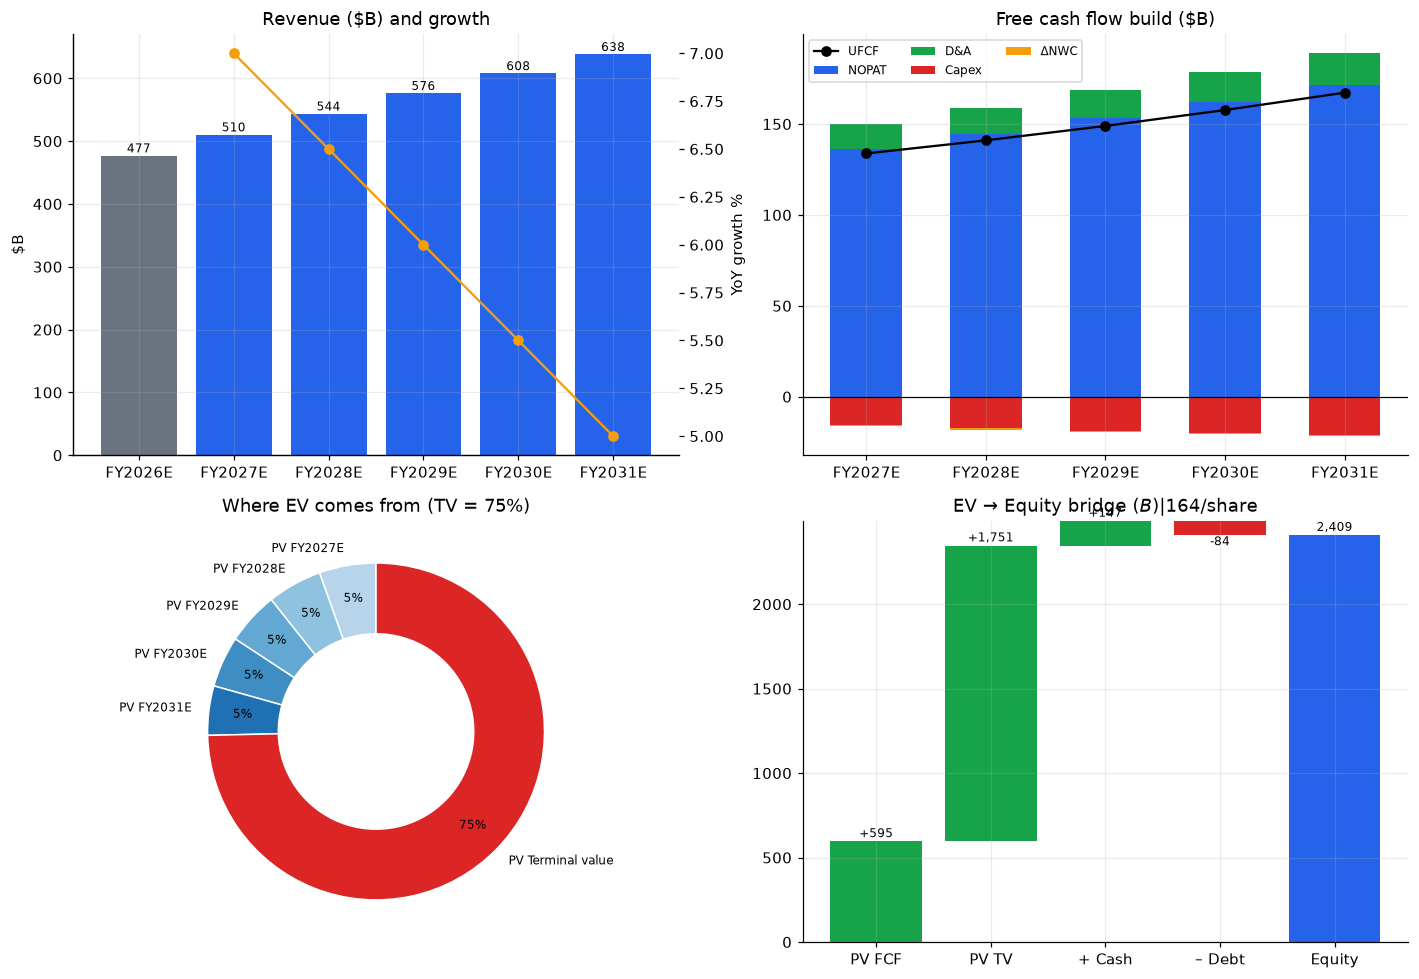

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) Revenue + growth
a = ax[0,0]; hist = ["FY2026E"]+years
revs = [p["rev0"]] + list(df.Revenue)
a.bar(hist, np.array(revs)/1e3, color=[GREY]+[BLUE]*5)
a.set_title("Revenue ($B) and growth"); a.set_ylabel("$B")
a2 = a.twinx(); a2.plot(years, df.Growth*100, color=ORANGE, marker="o"); a2.set_ylabel("YoY growth %"); a2.grid(False)
for i, v in enumerate(revs): a.text(i, v/1e3+5, f"{v/1e3:,.0f}", ha="center", fontsize=8)

# (b) UFCF build
b = ax[0,1]; x = np.arange(5); w = .6
b.bar(x, df.NOPAT/1e3, w, label="NOPAT", color=BLUE)
b.bar(x, df.DA/1e3, w, bottom=df.NOPAT/1e3, label="D&A", color=GREEN)
b.bar(x, -df.Capex/1e3, w, label="Capex", color=RED)
b.bar(x, -df.dNWC/1e3, w, bottom=-df.Capex/1e3, label="ΔNWC", color=ORANGE)
b.plot(x, df.UFCF/1e3, "k-o", label="UFCF")
b.set_xticks(x); b.set_xticklabels(years); b.axhline(0, color="k", lw=.8)
b.set_title("Free cash flow build ($B)"); b.legend(ncol=3, fontsize=8)

# (c) PV composition donut
c = ax[1,0]
vals = list(df.PV) + [R["pv_tv"]]; labs = [f"PV {y}" for y in years] + ["PV Terminal value"]
cols = plt.cm.Blues(np.linspace(.3,.75,5)).tolist() + [RED]
c.pie(vals, labels=labs, colors=cols, autopct="%1.0f%%", startangle=90, pctdistance=.8,
      wedgeprops=dict(width=.42, edgecolor="w"), textprops=dict(fontsize=8))
c.set_title(f"Where EV comes from (TV = {R['tv_share']:.0%})"); c.grid(False)

# (d) EV -> per-share waterfall
d = ax[1,1]
steps = [("PV FCF", R["pv_fcf"]), ("PV TV", R["pv_tv"]), ("+ Cash", p["cash"]), ("– Debt", -p["debt"])]
cum = 0
for i,(n,v) in enumerate(steps):
    d.bar(i, v/1e3, bottom=cum/1e3, color=GREEN if v>0 else RED); 
    d.text(i, (cum+v)/1e3 + (25 if v>0 else -60), f"{v/1e3:+,.0f}", ha="center", fontsize=8); cum += v
d.bar(len(steps), cum/1e3, color=BLUE); d.text(len(steps), cum/1e3+25, f"{cum/1e3:,.0f}", ha="center", fontsize=8)
d.set_xticks(range(len(steps)+1)); d.set_xticklabels([s[0] for s in steps]+["Equity"])
d.set_title(f"EV → Equity bridge ($B) | ${R['per_share']:,.0f}/share"); 
plt.tight_layout(); plt.show()

## 5. Sensitivity heatmaps

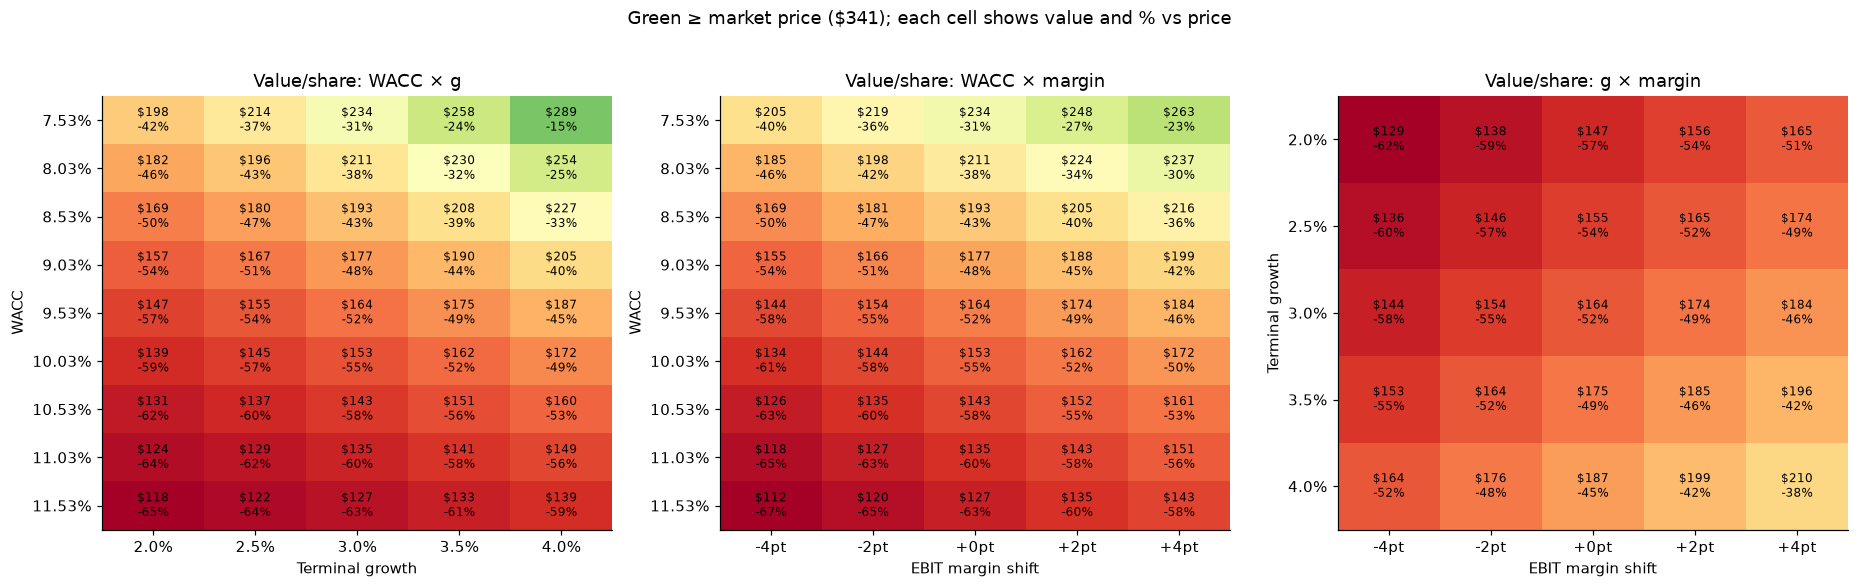

In [5]:
def heat(ax, z, xl, yl, xlab, ylab, title, xfmt=None, yfmt=None):
    im = ax.imshow(z, cmap="RdYlGn", aspect="auto", vmin=z.min(), vmax=max(z.max(), p["price"]))
    ax.set_xticks(range(len(xl))); ax.set_xticklabels(xl); ax.set_yticks(range(len(yl))); ax.set_yticklabels(yl)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab); ax.set_title(title); ax.grid(False)
    for i in range(z.shape[0]):
        for j in range(z.shape[1]):
            up = z[i,j]/p["price"]-1
            ax.text(j, i, f"${z[i,j]:,.0f}\n{up:+.0%}", ha="center", va="center", fontsize=8)
    return im

waccs = np.round(np.arange(R["wacc"]-.02, R["wacc"]+.0201, .005), 4)
gs    = np.array([.02,.025,.03,.035,.04])
shifts= np.array([-.04,-.02,0,.02,.04])
z1 = np.array([[vps(wacc_override=w, g=g) for g in gs] for w in waccs])
z2 = np.array([[vps(wacc_override=w, margin_shift=s) for s in shifts] for w in waccs])
z3 = np.array([[vps(g=g, margin_shift=s) for s in shifts] for g in gs])

fig, ax = plt.subplots(1, 3, figsize=(17, 5.2))
heat(ax[0], z1, [f"{g:.1%}" for g in gs], [f"{w:.2%}" for w in waccs], "Terminal growth", "WACC", "Value/share: WACC × g")
heat(ax[1], z2, [f"{s*100:+.0f}pt" for s in shifts], [f"{w:.2%}" for w in waccs], "EBIT margin shift", "WACC", "Value/share: WACC × margin")
heat(ax[2], z3, [f"{s*100:+.0f}pt" for s in shifts], [f"{g:.1%}" for g in gs], "EBIT margin shift", "Terminal growth", "Value/share: g × margin")
plt.suptitle(f"Green ≥ market price (${p['price']:,.0f}); each cell shows value and % vs price", y=1.02); plt.tight_layout(); plt.show()

## 6. Tornado — what moves value most?

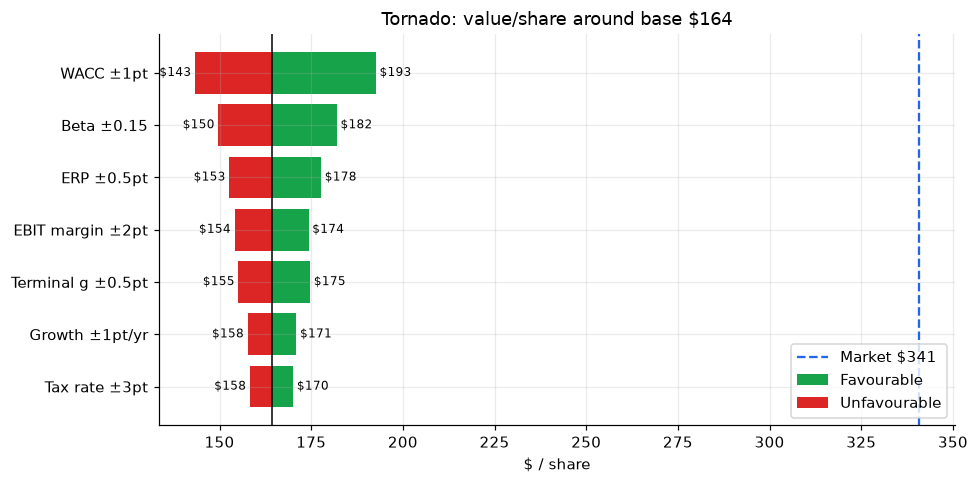

In [6]:
base = R["per_share"]
tests = {
    "WACC ±1pt":            (dict(wacc_override=R["wacc"]-.01), dict(wacc_override=R["wacc"]+.01)),
    "Terminal g ±0.5pt":    (dict(g=p["g"]+.005),               dict(g=p["g"]-.005)),
    "EBIT margin ±2pt":     (dict(margin_shift=.02),            dict(margin_shift=-.02)),
    "Growth ±1pt/yr":       (dict(growth_shift=.01),            dict(growth_shift=-.01)),
    "Beta ±0.15":           (dict(beta=p["beta"]-.15),          dict(beta=p["beta"]+.15)),
    "ERP ±0.5pt":           (dict(erp=p["erp"]-.005),           dict(erp=p["erp"]+.005)),
    "Tax rate ±3pt":        (dict(tax=p["tax"]-.03),            dict(tax=p["tax"]+.03)),
}
T = pd.DataFrame({k:(vps(**a), vps(**b)) for k,(a,b) in tests.items()}, index=["up","down"]).T
T["range"] = (T.up-T.down).abs(); T = T.sort_values("range")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(T.index, T.up-base, left=base, color=GREEN, label="Favourable")
ax.barh(T.index, T.down-base, left=base, color=RED, label="Unfavourable")
ax.axvline(base, color="k", lw=1); ax.axvline(p["price"], color=BLUE, ls="--", label=f"Market ${p['price']:,.0f}")
for i,(u,d_) in enumerate(zip(T.up, T.down)):
    ax.text(max(u,d_)+1, i, f"${max(u,d_):,.0f}", va="center", fontsize=8); ax.text(min(u,d_)-1, i, f"${min(u,d_):,.0f}", va="center", ha="right", fontsize=8)
ax.set_title(f"Tornado: value/share around base ${base:,.0f}"); ax.set_xlabel("$ / share"); ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 7. Scenarios

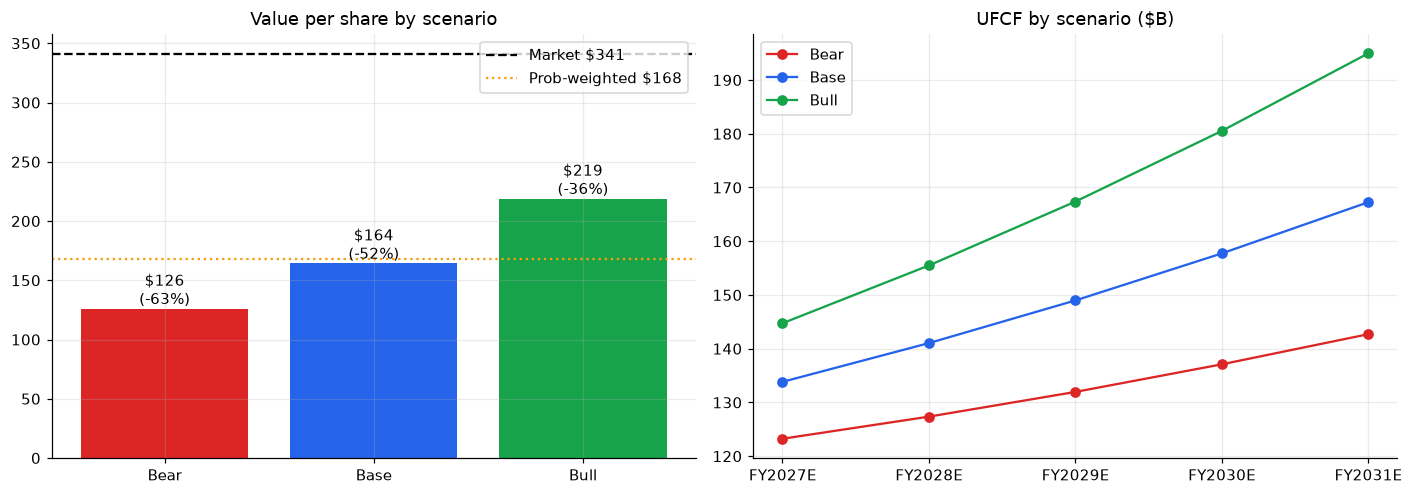

,Bear,Base,Bull
WACC,10.03%,9.53%,9.03%
g,2.5%,3.0%,3.5%
EV ($B),"1,786","2,346","3,148"
Value/share,$126,$164,$219
vs price,-63%,-52%,-36%


In [7]:
scen = {
  "Bear": dict(growth_shift=-.02, margin_shift=-.02, g=.025, wacc_override=R["wacc"]+.005),
  "Base": dict(),
  "Bull": dict(growth_shift=+.02, margin_shift=+.02, g=.035, wacc_override=R["wacc"]-.005),
}
S = {k: dcf(**v) for k,v in scen.items()}
prob = {"Bear":.25, "Base":.50, "Bull":.25}          # edit probabilities
pw = sum(prob[k]*S[k]["per_share"] for k in S)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
cols = [RED, BLUE, GREEN]
ax[0].bar(S.keys(), [s["per_share"] for s in S.values()], color=cols)
ax[0].axhline(p["price"], color="k", ls="--", label=f"Market ${p['price']:,.0f}")
ax[0].axhline(pw, color=ORANGE, ls=":", label=f"Prob-weighted ${pw:,.0f}")
for i,s in enumerate(S.values()): ax[0].text(i, s["per_share"]+4, f"${s['per_share']:,.0f}\n({s['per_share']/p['price']-1:+.0%})", ha="center")
ax[0].set_title("Value per share by scenario"); ax[0].legend()
for (k,s),c in zip(S.items(), cols): ax[1].plot(years, s["df"].UFCF/1e3, marker="o", color=c, label=k)
ax[1].set_title("UFCF by scenario ($B)"); ax[1].legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame({k:{"WACC":f"{s['wacc']:.2%}","g":f"{s['p']['g']:.1%}","EV ($B)":f"{s['ev']/1e3:,.0f}",
    "Value/share":f"${s['per_share']:,.0f}","vs price":f"{s['per_share']/p['price']-1:+.0%}"} for k,s in S.items()}))

## 8. Reverse DCF — what is the market pricing in?

To justify $340.67, holding everything else at base:
  • WACC would need to be     6.08%  (base 9.53%)
  • Terminal growth would be   6.80%  (base 3.0%)
  • EBIT margin shift would be +35.0pt every year (FY31 margin ≈ 67.6%)
  • Growth shift would be      +19.0pt every year


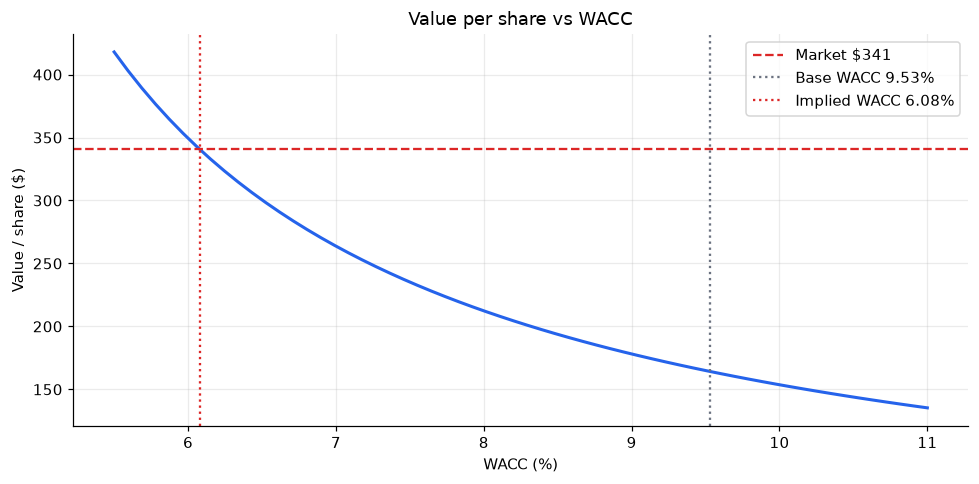

In [8]:
f_w = lambda w: vps(wacc_override=w) - p["price"]
f_g = lambda g: vps(g=g, wacc_override=R["wacc"]) - p["price"]
f_m = lambda s: vps(margin_shift=s) - p["price"]
f_gr= lambda s: vps(growth_shift=s) - p["price"]
impl_w  = brentq(f_w, p["g"]+.005, .20)
impl_g  = brentq(f_g, 0.0, R["wacc"]-.005)
impl_m  = brentq(f_m, -.1, .6)
impl_gr = brentq(f_gr, -.1, .3)

print(f"To justify ${p['price']:,.2f}, holding everything else at base:")
print(f"  • WACC would need to be     {impl_w:.2%}  (base {R['wacc']:.2%})")
print(f"  • Terminal growth would be   {impl_g:.2%}  (base {p['g']:.1%})")
print(f"  • EBIT margin shift would be {impl_m*100:+.1f}pt every year (FY31 margin ≈ {(p['ebit_m'][-1]+impl_m):.1%})")
print(f"  • Growth shift would be      {impl_gr*100:+.1f}pt every year")

ww = np.linspace(.055, .11, 60); vv = [vps(wacc_override=w) for w in ww]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ww*100, vv, color=BLUE, lw=2); ax.axhline(p["price"], color=RED, ls="--", label=f"Market ${p['price']:,.0f}")
ax.axvline(R["wacc"]*100, color=GREY, ls=":", label=f"Base WACC {R['wacc']:.2%}"); ax.axvline(impl_w*100, color=RED, ls=":", label=f"Implied WACC {impl_w:.2%}")
ax.set_xlabel("WACC (%)"); ax.set_ylabel("Value / share ($)"); ax.set_title("Value per share vs WACC"); ax.legend(); plt.tight_layout(); plt.show()

## 9. Monte Carlo

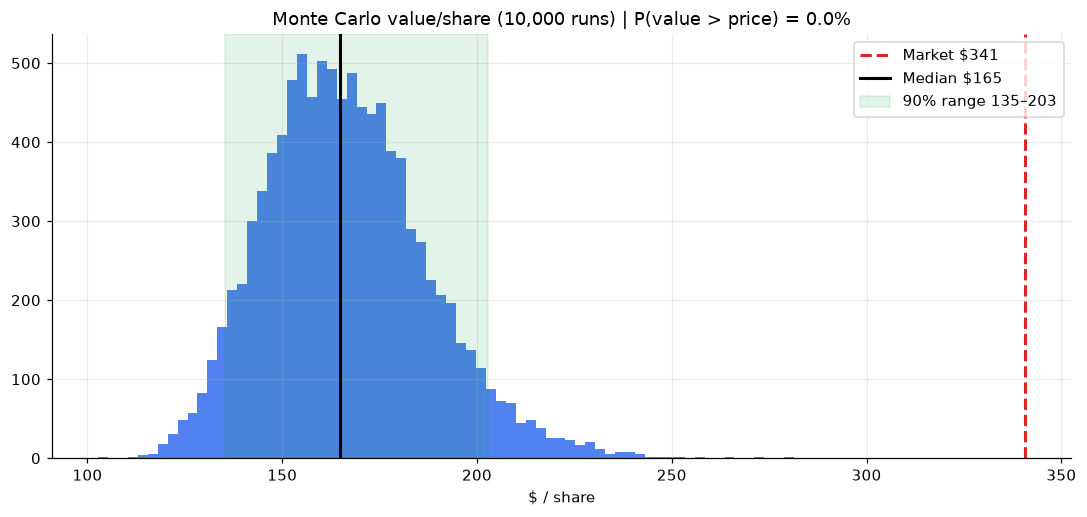

,Value/share
0.050000,$135
0.250000,$152
0.500000,$165
0.750000,$179
0.950000,$203


In [9]:
rng = np.random.default_rng(42); N = 10_000
draw = pd.DataFrame({
    "beta":  rng.normal(p["beta"], .10, N),
    "erp":   rng.normal(p["erp"], .005, N),
    "g":     np.clip(rng.normal(p["g"], .004, N), .01, .045),
    "gshift":rng.normal(0, .01, N),
    "mshift":rng.normal(0, .01, N),
})
def one(r):
    try:
        res = dcf(beta=r.beta, erp=r.erp, g=r.g, growth_shift=r.gshift, margin_shift=r.mshift)
        return res["per_share"] if res["wacc"] - r.g > .02 else np.nan
    except Exception: return np.nan
sims = draw.apply(one, axis=1).dropna()
pct = sims.quantile([.05,.25,.5,.75,.95])
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.hist(sims, bins=70, color=BLUE, alpha=.8)
ax.axvline(p["price"], color=RED, ls="--", lw=2, label=f"Market ${p['price']:,.0f}")
ax.axvline(sims.median(), color="k", lw=2, label=f"Median ${sims.median():,.0f}")
ax.axvspan(pct[.05], pct[.95], color=GREEN, alpha=.12, label=f"90% range ${pct[.05]:,.0f}–${pct[.95]:,.0f}")
ax.set_title(f"Monte Carlo value/share ({len(sims):,} runs) | P(value > price) = {(sims>p['price']).mean():.1%}")
ax.set_xlabel("$ / share"); ax.legend(); plt.tight_layout(); plt.show()
display(pct.rename("Value/share").to_frame().style.format("${:,.0f}"))

## 10. Export

In [10]:
out = "dcf_output.xlsx"
with pd.ExcelWriter(out) as xw:
    show.to_excel(xw, sheet_name="Projections", index=False)
    summary.to_frame().to_excel(xw, sheet_name="Summary")
    pd.DataFrame(z1, index=[f"{w:.2%}" for w in waccs], columns=[f"{g:.1%}" for g in gs]).to_excel(xw, sheet_name="Sens_WACC_g")
try:
    from google.colab import files; files.download(out)
except ImportError:
    print("Saved", out)

ModuleNotFoundError: No module named 'openpyxl'